In [191]:
# Importa a biblioteca pandas para manipulação de dados em DataFrames
import pandas as pd

# Importa a biblioteca numpy para operações numéricas
import numpy as np

# Importa a função para modelos lineares do statsmodels usando fórmulas
import statsmodels.formula.api as smf

# Importa seaborn para visualização de dados estatísticos
import seaborn as sns

# Importa o módulo pyplot do matplotlib para criação de gráficos
import matplotlib.pyplot as plt

# Importa a API principal do statsmodels para análise estatística
import statsmodels.api as sm

# Importa função para dividir os dados em treino e teste
from sklearn.model_selection import train_test_split

# Importa a função para cálculo do VIF (Variance Inflation Factor)
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from statsmodels.tools.tools import add_constant

import unicodedata

from statsmodels.graphics.regressionplots import influence_plot

from sklearn.metrics import mean_squared_error


In [153]:
previsao_renda = pd.read_csv('./Dataset/previsao_de_renda_II.csv')  # Lê o arquivo CSV com os dados e armazena no DataFrame
previsao_renda.loc[previsao_renda['tempo_emprego'].isna(), 'tempo_emprego'] = previsao_renda.tempo_emprego.mean()  # Substitui valores ausentes em 'tempo_emprego' pela média da coluna

In [154]:
# Função para criar dataframe VIF e realizar a filtragem de variáveis que possuírem um valor acima do estipulado nos parâmetros
def vif_filter(X, limite=10):
    """
    Filtra variáveis com alto fator de inflação de variância (VIF) de um DataFrame.

    Parâmetros:
    X (pd.DataFrame): DataFrame contendo apenas variáveis numéricas independentes.
    limite (float): Valor limite de VIF para remoção de variáveis (padrão=10).

    Retorna:
    X_filtrado (pd.DataFrame): DataFrame com variáveis remanescentes após filtragem.
    removed_features (list): Lista de tuplas (variável, VIF) removidas.
    remaining_vif (pd.DataFrame): DataFrame com VIF das variáveis remanescentes.
    """
    X_filtrado = X.copy()  # Cria uma cópia do DataFrame original
    removed_features = []  # Lista para armazenar variáveis removidas
    vif_scores = {}        # Dicionário para armazenar os VIFs

    while True:
        # Adiciona constante para cálculo do VIF
        X_with_const = add_constant(X_filtrado)

        # Calcula o VIF para cada variável (incluindo a constante)
        vif_data = pd.DataFrame()
        vif_data["feature"] = X_with_const.columns
        vif_data["VIF"] = [vif(X_with_const.values, i)
                           for i in range(X_with_const.shape[1])]

        # Remove a constante da análise
        vif_data = vif_data[vif_data['feature'] != 'const']

        # Salva os VIFs calculados
        for _, row in vif_data.iterrows():
            vif_scores[row['feature']] = row['VIF']

        # Verifica o maior VIF
        max_vif = vif_data['VIF'].max()
        if max_vif <= limite:
            break  # Sai do loop se todos os VIFs estiverem abaixo do limite

        # Remove a variável com maior VIF
        feature_to_remove = vif_data.loc[vif_data['VIF'].idxmax(), 'feature']
        removed_features.append((feature_to_remove, max_vif))
        X_filtrado = X_filtrado.drop(columns=[feature_to_remove])

        # Se todas as variáveis forem removidas, lança erro
        if X_filtrado.shape[1] == 0:
            raise ValueError("Todas as variáveis foram removidas - limite pode estar muito baixo")

    # Monta DataFrame final com VIF das variáveis remanescentes
    remaining_vif = vif_data[vif_data['feature'].isin(X_filtrado.columns)]
    remaining_vif = remaining_vif.sort_values('VIF', ascending=False)

    return X_filtrado, removed_features, remaining_vif



# Função para remover caracteres especiais e adicionar "_" nos espaços
def padronizar_nome(var):
    """
    Remove caracteres especiais de uma string e substitui espaços por underline.

    Parâmetros:
    var (str): Nome da variável a ser padronizado.

    Retorna:
    str: Nome padronizado, sem acentos e com espaços substituídos por "_".
    """
    # Normaliza a string para remover acentos e caracteres especiais
    var = unicodedata.normalize('NFKD', var).encode('ASCII', 'ignore').decode('ASCII')
    return var.replace(' ', '_')  # Substitui espaços por underline



def esp_vs_obs(data, res, X, y_pred, y_true, transformar=False, amostragem=False, tamanho=1000):
    # Obtém as previsões do modelo OLS
    pred_ols = res.get_prediction()
    pred_summary = pred_ols.summary_frame()

    # Extrai intervalos de confiança para observações e médias
    iv_l = pred_summary['obs_ci_lower']
    iv_u = pred_summary['obs_ci_upper']
    m_l = pred_summary['mean_ci_lower']
    m_u = pred_summary['mean_ci_upper']

    # Se amostragem for True, utiliza apenas as primeiras 'tamanho' linhas
    if amostragem:
        data = data.head(tamanho)
        y_pred = y_pred.head(tamanho)
        iv_l = iv_l.head(tamanho)
        iv_u = iv_u.head(tamanho)
        m_l = m_l.head(tamanho)
        m_u = m_u.head(tamanho)

    # Cria uma cópia do dataframe ordenado pelo eixo X
    df_plot = data.copy()
    df_plot["y_pred"] = y_pred
    df_plot["iv_l"] = iv_l
    df_plot["iv_u"] = iv_u
    df_plot["m_l"] = m_l
    df_plot["m_u"] = m_u
    # Se transformar=True, aplica log na variável resposta real
    df_plot["y_real"] = np.log(data[y_true]) if transformar else data[y_true]
    df_plot = df_plot.sort_values(by=X)

    fig, ax = plt.subplots(figsize=(8, 6))

    # Scatter dos pontos observados
    ax.plot(df_plot[X], df_plot["y_pred"], 'o', label="Dados observados", alpha=0.5)

    # Linhas conectando em ordem
    ax.plot(df_plot[X], df_plot["y_real"], 'b-', label='Média da simulação (log)' if transformar else 'Média da simulação')
    ax.plot(df_plot[X], df_plot["y_pred"], 'r--', label='Estimativa OLS')
    ax.plot(df_plot[X], df_plot["iv_u"], 'r--', label='Banda de confiança para y')
    ax.plot(df_plot[X], df_plot["iv_l"], 'r--')
    ax.plot(df_plot[X], df_plot["m_u"], 'g:', label='Banda de confiança para média')
    ax.plot(df_plot[X], df_plot["m_l"], 'g:')

    ax.set_xlabel(X)
    ax.set_ylabel(y_true)
    ax.set_title("Expectativa vs Observado")
    ax.legend(loc='best')
    plt.tight_layout()
    plt.show()
    
def stepwise_selection(
    X, y, initial_list=[], threshold_in=0.01, threshold_out=0.05, verbose=True
):
    """Perform a forward-backward feature selection
    based on p-value from statsmodels.api.OLS
    Arguments:
        X - pandas.DataFrame with candidate features
        y - list-like with the target
        initial_list - list of features to start with (column names of X)
        threshold_in - include a feature if its p-value < threshold_in
        threshold_out - exclude a feature if its p-value > threshold_out
        verbose - whether to print the sequence of inclusions and exclusions
    Returns: list of selected features
    Always set threshold_in < threshold_out to avoid infinite looping.
    See https://en.wikipedia.org/wiki/Stepwise_regression for the details
    """
    included = list(initial_list)
    while True:
        changed = False
        # forward step
        excluded = list(set(X.columns) - set(included))
        new_pval = pd.Series(index=excluded)
        for new_column in excluded:
            model = sm.OLS(
                y, sm.add_constant(pd.DataFrame(X[included + [new_column]]))
            ).fit()
            new_pval[new_column] = model.pvalues[new_column]
        best_pval = new_pval.min()
        if best_pval < threshold_in:
            best_feature = new_pval.idxmin()  # Use idxmin() em vez de argmin() para garantir o nome da coluna
            included.append(best_feature)
            changed = True
            if verbose:
                print("Add  {:30} with p-value {:.6}".format(best_feature, best_pval))

        # backward step
        model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included]))).fit()
        # use all coefs except intercept
        pvalues = model.pvalues.iloc[1:]
        worst_pval = pvalues.max()  # null if pvalues is empty
        if worst_pval > threshold_out:
            changed = True
            worst_feature = pvalues.idxmax()  # Use idxmax() em vez de argmax() para garantir o nome da coluna
            included.remove(worst_feature)
            if verbose:
                print("Drop {:30} with p-value {:.6}".format(worst_feature, worst_pval))
        if not changed:
            break
    return included

## Multicolinearidade

Avalie se há questões relacionadas a multicolinearidade através de pelo menos:

- Matriz de correlação de Spearman
- VIF

In [155]:
# Obtém a lista de todas as colunas do DataFrame df
variaveis = previsao_renda.columns.to_list()

# Remove as colunas 'data_ref' e 'index' da lista de variáveis, pois não serão usadas nas análises
variaveis = [x for x in variaveis if x not in ['data_ref', 'index']]

# Calcula a matriz de correlação de Spearman apenas para as variáveis numéricas do dataframe 'df'
correlacao_spearmen = previsao_renda[variaveis].select_dtypes(include=['float64', 'int64']).corr(method='spearman')

# Substitui os valores da diagonal principal por NaN para facilitar a visualização (evita destacar a correlação perfeita de uma variável consigo mesma)
np.fill_diagonal(correlacao_spearmen.values, np.nan)
        
# Aplica o destaque (highlight) ao maior valor de cada linha da matriz de correlação de Spearman,
# usando a cor preta para facilitar a visualização dos pares de variáveis com maior correlação em cada linha.
correlacao_spearmen.style.highlight_max(axis=1, color='black')

,qtd_filhos,idade,tempo_emprego,qt_pessoas_residencia,renda
qtd_filhos,nan,-0.415151,-0.089260,0.828600,-0.019957
idade,-0.415151,nan,0.300547,-0.350006,0.107999
tempo_emprego,-0.089260,0.300547,nan,-0.058139,0.501354
qt_pessoas_residencia,0.828600,-0.350006,-0.058139,nan,-0.008260
renda,-0.019957,0.107999,0.501354,-0.008260,nan


In [156]:
# Cria variáveis dummies para as variáveis categóricas presentes em 'variaveis' do DataFrame 'df'
# drop_first=True remove a primeira categoria de cada variável para evitar multicolinearidade (dummy variable trap)
# dtype=int garante que as colunas criadas sejam do tipo inteiro
previsao_renda_dummies_numericas = pd.get_dummies(
    data=previsao_renda[variaveis], drop_first=True, dtype=int
)

# Define a variável dependente (target) como a nova coluna 'log_renda'
y = previsao_renda['renda']

# Define as variáveis independentes removendo as colunas 'renda' e 'log_renda'
X = previsao_renda.drop(columns=['renda'])

# Separa os dados em treino e teste (60% treino, 40% teste, com semente fixa para reprodutibilidade)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=100)

# Junta as variáveis independentes e dependente para formar o dataframe de treino
df_treino = X_train.join(y_train)

# Junta as variáveis independentes e dependente para formar o dataframe de teste
df_teste = X_test.join(y_test)

# Seleciona uma amostra de 30.000 linhas do conjunto de treino para análise de resíduos
df_resid_check = df_treino.sample(30000, random_state=100).reset_index(drop=True)


# Renomeia as colunas do DataFrame aplicando a função de padronização de nomes
previsao_renda_dummies_numericas = previsao_renda_dummies_numericas.rename(columns=padronizar_nome)

# Cria uma lista com todas as variáveis independentes, exceto 'renda'
variaveis_independentes = [var for var in previsao_renda_dummies_numericas.columns.to_list() if var != 'renda']

# Monta a string da fórmula para o modelo de regressão linear
formula = "renda ~ " + " + ".join(variaveis_independentes)

# Ajusta o modelo de regressão linear com a fórmula e os dados
r1 = smf.ols(
    formula,
    data=previsao_renda_dummies_numericas
).fit()

r1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  renda   R-squared:                       0.218
Model:                            OLS   Adj. R-squared:                  0.218
Method:                 Least Squares   F-statistic:                     8736.
Date:                Mon, 14 Jul 2025   Prob (F-statistic):               0.00
Time:                        20:31:20   Log-Likelihood:            -9.5308e+06
No. Observations:              750000   AIC:                         1.906e+07
Df Residuals:                  749975   BIC:                         1.906e+07
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
=================================================================================================
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                     -3.729e+04   3713.392    -10.043      0.000   -4.46e+04      -3e+04
qtd_filhos                    -1216.8220   1750.251     -0.695      0.487   -4647.257    2213.613
idade                           275.3811     12.087     22.783      0.000     251.691     299.071
tempo_emprego                  6687.2758     16.271    410.992      0.000    6655.385    6719.167
qt_pessoas_residencia           300.1166   1746.538      0.172      0.864   -3123.040    3723.274
sexo_M                        -2721.8917    217.934    -12.489      0.000   -3149.036   -2294.747
posse_de_veiculo_S             -816.4765    207.233     -3.940      0.000   -1222.647    -410.306
posse_de_imovel_S              5587.9791    202.780     27.557      0.000    5190.536    5985.422
tipo_renda_Bolsista           -3.312e+04   4124.059     -8.031      0.000   -4.12e+04    -2.5e+04
tipo_renda_Empresario          2323.9973    233.848      9.938      0.000    1865.663    2782.332
tipo_renda_Pensionista        -2.153e+04    333.742    -64.502      0.000   -2.22e+04   -2.09e+04
tipo_renda_Servidor_publico    -262.1285    344.101     -0.762      0.446    -936.555     412.298
educacao_Medio                -2667.8349    876.894     -3.042      0.002   -4386.519    -949.151
educacao_Pos_graduacao         6300.1949   2958.800      2.129      0.033     501.045    1.21e+04
educacao_Superior_completo    -1226.8484    884.768     -1.387      0.166   -2960.965     507.268
educacao_Superior_incompleto   4132.4120    991.224      4.169      0.000    2189.645    6075.179
estado_civil_Separado          1585.2603   1792.339      0.884      0.376   -1927.666    5098.187
estado_civil_Solteiro          9028.3729   1758.174      5.135      0.000    5582.410    1.25e+04
estado_civil_Uniao              904.8148    352.209      2.569      0.010     214.498    1595.132
estado_civil_Viuvo             -632.0469   1811.931     -0.349      0.727   -4183.372    2919.278
tipo_residencia_Casa          -1605.4287    793.217     -2.024      0.043   -3160.109     -50.749
tipo_residencia_Com_os_pais    2207.3627    899.601      2.454      0.014     444.175    3970.550
tipo_residencia_Comunitario    3022.2969   1604.861      1.883      0.060    -123.179    6167.773
tipo_residencia_Estudio       -4627.8536   1341.766     -3.449      0.001   -7257.671   -1998.036
tipo_residencia_Governamental -5239.4825    945.534     -5.541      0.000   -7092.698   -3386.266
==============================================================================
Omnibus:                  1840375.888   Durbin-Watson:                   1.928
Prob(Omnibus):                  0.000   Jarque-Bera (JB):      49429691063.961
Skew:                          25.959   Prob(JB):                         0.00
Kurtosis:              

In [157]:
# Aplica a função vif_filter para remover variáveis com VIF acima de 5, retornando o dataframe ajustado, as variáveis removidas e o dataframe com os VIFs finais
previsao_renda_vif_ajustado, variaveis_removidas, vif_frame = vif_filter(previsao_renda_dummies_numericas.drop(columns=['renda']), 5)

# Monta a fórmula para o modelo de regressão linear usando apenas as variáveis remanescentes após o filtro de VIF
formula = "I(np.log(renda + 1)) ~ " + " + ".join(vif_frame.feature)

# Ajusta o modelo de regressão linear com a nova fórmula e os dados originais (com dummies)
r2 = smf.ols(
    formula,
    data=previsao_renda_dummies_numericas
).fit()

# Exibe o resumo do modelo ajustado
r2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                             
================================================================================
Dep. Variable:     I(np.log(renda + 1))   R-squared:                       0.393
Model:                              OLS   Adj. R-squared:                  0.393
Method:                   Least Squares   F-statistic:                 2.315e+04
Date:                  Mon, 14 Jul 2025   Prob (F-statistic):               0.00
Time:                          20:33:51   Log-Likelihood:            -1.0643e+06
No. Observations:                750000   AIC:                         2.129e+06
Df Residuals:                    749978   BIC:                         2.129e+06
Df Model:                            21                                         
Covariance Type:              nonrobust                                         
=================================================================================================
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         7.7167      0.007   1088.875      0.000       7.703       7.731
idade                             0.0035      0.000     23.276      0.000       0.003       0.004
tipo_renda_Pensionista           -0.2963      0.004    -71.027      0.000      -0.304      -0.288
sexo_M                            0.1269      0.003     46.556      0.000       0.122       0.132
qtd_filhos                        0.0047      0.002      2.740      0.006       0.001       0.008
posse_de_veiculo_S                0.0151      0.003      5.819      0.000       0.010       0.020
tempo_emprego                     0.1289      0.000    633.370      0.000       0.129       0.129
tipo_renda_Empresario             0.1526      0.003     52.161      0.000       0.147       0.158
tipo_renda_Servidor_publico       0.1461      0.004     33.919      0.000       0.138       0.154
estado_civil_Viuvo                0.0074      0.006      1.227      0.220      -0.004       0.019
estado_civil_Solteiro             0.0094      0.004      2.567      0.010       0.002       0.017
educacao_Superior_completo       -0.0063      0.003     -2.536      0.011      -0.011      -0.001
tipo_residencia_Com_os_pais       0.0313      0.006      5.404      0.000       0.020       0.043
posse_de_imovel_S                 0.1867      0.003     73.611      0.000       0.182       0.192
educacao_Superior_incompleto     -0.0198      0.006     -3.236      0.001      -0.032      -0.008
estado_civil_Separado             0.0305      0.005      5.995      0.000       0.021       0.040
estado_civil_Uniao                0.0017      0.004      0.379      0.705      -0.007       0.010
tipo_residencia_Governamental    -0.0136      0.007     -2.032      0.042      -0.027      -0.000
tipo_residencia_Estudio          -0.0394      0.014     -2.881      0.004      -0.066      -0.013
tipo_residencia_Comunitario      -0.0411      0.018     -2.343      0.019      -0.076      -0.007
tipo_renda_Bolsista              -0.1580      0.052     -3.061      0.002      -0.259      -0.057
educacao_Pos_graduacao            0.0639      0.035      1.805      0.071      -0.005       0.133
==============================================================================
Omnibus:                     3983.688   Durbin-Watson:                   1.036
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2868.923
Skew:                          -0.022   Prob(JB):                         0.00
Kurtosis:                       2.700   Cond. No.                     2.05e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.

In [158]:
previsao_renda_vif_ajustado.select_dtypes(include=['float64', 'int64'])

,qtd_filhos,idade,tempo_emprego
0,0,47,16.717808
1,0,30,9.600000
2,0,28,8.208219
3,2,44,1.301370
4,2,33,1.254795
...,...,...,...
749995,1,29,8.665753
749996,0,65,7.746165
749997,0,33,10.969863
749998,1,28,8.219178


## Linearização de resíduos

In [159]:
# Definir pontos de corte para testar
C1_values = np.linspace(start=previsao_renda['tempo_emprego'].min(),
                       stop=previsao_renda['tempo_emprego'].max(),
                       num=5)  # Reduzindo para 5 pontos para cada variável

C2_values = np.linspace(start=previsao_renda['qtd_filhos'].min(),
                       stop=previsao_renda['qtd_filhos'].max(),
                       num=5)

C3_values = np.linspace(start=previsao_renda['idade'].min(),
                       stop=previsao_renda['idade'].max(),
                       num=5)

# Lista para armazenar resultados
resultados = []

# Testar combinações de pontos de corte
for c1 in C1_values:
    # Criar segmentos para tempo_emprego
    df_resid_check['X1_1'] = np.where(df_resid_check['tempo_emprego'] <= c1, 
                                     df_resid_check['tempo_emprego'], c1)
    df_resid_check['X1_2'] = np.where(df_resid_check['tempo_emprego'] > c1, 
                                     df_resid_check['tempo_emprego'] - c1, 0)
    
    for c2 in C2_values:
        # Criar segmentos para qtd_filhos
        df_resid_check['X2_1'] = np.where(df_resid_check['qtd_filhos'] <= c2, 
                                         df_resid_check['qtd_filhos'], c2)
        df_resid_check['X2_2'] = np.where(df_resid_check['qtd_filhos'] > c2, 
                                         df_resid_check['qtd_filhos'] - c2, 0)
        
        for c3 in C3_values:
            # Criar segmentos para idade
            df_resid_check['X3_1'] = np.where(df_resid_check['idade'] <= c3, 
                                            df_resid_check['idade'], c3)
            df_resid_check['X3_2'] = np.where(df_resid_check['idade'] > c3, 
                                            df_resid_check['idade'] - c3, 0)
            
            # Ajustar modelo
            formula = 'I(np.log(renda+1)) ~ I(np.log(X1_1 + 10)) + I(np.log(X1_2 + 10)) + X2_1 + X2_2 + I(np.log(X3_1 + 10)) + I(np.log(X3_2 + 10))'
            try:
                modelo = smf.ols(formula, data=df_resid_check).fit()
                
                # Armazenar resultados
                resultados.append({
                    'corte_tempo_emprego': c1,
                    'corte_qtd_filhos': c2,
                    'corte_idade': c3,
                    'R2': modelo.rsquared,
                    'AIC': modelo.aic,
                    'BIC': modelo.bic
                })
            except:
                continue

# Converter para DataFrame
df_resultados = pd.DataFrame(resultados)

# Mostrar melhores combinações
df_resultados.sort_values('R2', ascending=False).head(10)

,corte_tempo_emprego,corte_qtd_filhos,corte_idade,R2,AIC,BIC
32,10.815068,3.5,45.0,0.376620,85807.745564,85865.908233
42,10.815068,10.5,45.0,0.376601,85808.615997,85866.778666
37,10.815068,7.0,45.0,0.376601,85808.615997,85866.778666
27,10.815068,0.0,45.0,0.376601,85806.639124,85856.492840
47,10.815068,14.0,45.0,0.376601,85806.639124,85856.492840
33,10.815068,3.5,56.5,0.375967,85839.128269,85897.290938
43,10.815068,10.5,56.5,0.375959,85839.506706,85897.669374
38,10.815068,7.0,56.5,0.375959,85839.506706,85897.669374
28,10.815068,0.0,56.5,0.375959,85837.522634,85887.376350
48,10.815068,14.0,56.5,0.375959,85837.522634,85887.376350


In [219]:
C1 = 10.815068
C2 =  3.5
C3 = 45


### CRIANDO DOIS SEGMENTOS PARA A VARIÁVEL TEMPO_EMPREGO
# Cria a variável segmentada X1_1: igual a X1 se X1 <= C1, senão igual a C1
df_resid_check['X1_1'] = (df_resid_check['tempo_emprego'] <= C1) * df_resid_check['tempo_emprego'] + (df_resid_check['tempo_emprego'] > C1) * C1

# Cria a variável segmentada X1_2: igual a X1 - C1 se X1 > C1, senão zero
df_resid_check['X1_2'] = (df_resid_check['tempo_emprego'] > C1) * (df_resid_check['tempo_emprego'] - C1)


### CRIANDO DOIS SEGMENTOS PARA QTD_FILHOS
# Cria a variável segmentada X2_1: igual a qtd_filhos se qtd_filhos <= C2, senão igual a C2
df_resid_check['X2_1'] = (df_resid_check['qtd_filhos'] <= C2) * df_resid_check['qtd_filhos'] + (df_resid_check['qtd_filhos'] > C2) * C2

# Cria a variável segmentada X1_2: igual a qtd_filhos - C2 se X1 > C2, senão zero
df_resid_check['X2_2'] = (df_resid_check['qtd_filhos'] > C2) * (df_resid_check['qtd_filhos'] - C2)


### CRIANDO DOIS SEGMENTOS PARA A VARIÁVEL IDADE
# Cria a variável segmentada X3_1: igual a idade se idade <= C3, senão igual a C3
df_resid_check['X3_1'] = (df_resid_check['idade'] <= C3) * df_resid_check['idade'] + (df_resid_check['idade'] > C3) * C3

# Cria a variável segmentada X1_2: igual a X1 - C3 se X1 > C3, senão zero
df_resid_check['X3_2'] = (df_resid_check['idade'] > C3) * (df_resid_check['idade'] - C3)

# Separa os dados em treino e teste (60% treino, 40% teste, com semente fixa para reprodutibilidade)
X_train_, X_test_, y_train_, y_test_ = train_test_split(df_resid_check.drop(columns=('renda')), df_resid_check.renda, test_size=0.4, random_state=100)


# Ajusta o modelo de regressão linear segmentado usando as transformações logarítmicas das variáveis segmentadas
res_segmentada = smf.ols('I(np.log(renda+1)) ~ I(np.log(X1_1 + 2)) + I(np.log(X1_2 + 2)) + I(np.log(X2_1 + 2)) + I(np.log(X2_2 + 2))+ I(np.log(X3_1 + 2))  + I(np.log(X3_2 + 2))', data=X_train_.join(y_train_)).fit() 

R-quadrado: 36.80%


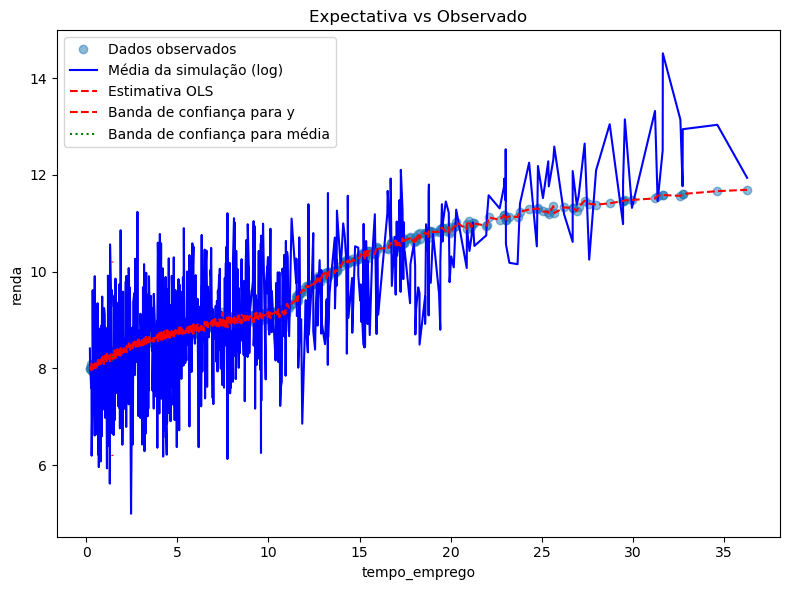

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                             
================================================================================
Dep. Variable:     I(np.log(renda + 1))   R-squared:                       0.368
Model:                              OLS   Adj. R-squared:                  0.368
Method:                   Least Squares   F-statistic:                     1746.
Date:                  Mon, 14 Jul 2025   Prob (F-statistic):               0.00
Time:                          20:33:55   Log-Likelihood:                -25879.
No. Observations:                 18000   AIC:                         5.177e+04
Df Residuals:                     17993   BIC:                         5.183e+04
Df Model:                             6                                         
Covariance Type:              nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               5.4848      0.299     18.316      0.000       4.898       6.072
I(np.log(X1_1 + 2))     0.6615      0.018     36.327      0.000       0.626       0.697
I(np.log(X1_2 + 2))     0.9997      0.015     67.080      0.000       0.971       1.029
I(np.log(X2_1 + 2))    -0.0069      0.033     -0.208      0.835      -0.072       0.059
I(np.log(X2_2 + 2))     0.4112      0.312      1.317      0.188      -0.201       1.023
I(np.log(X3_1 + 2))     0.3000      0.060      5.028      0.000       0.183       0.417
I(np.log(X3_2 + 2))    -0.0840      0.012     -7.096      0.000      -0.107      -0.061
==============================================================================
Omnibus:                       80.209   Durbin-Watson:                   2.013
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               59.939
Skew:                          -0.028   Prob(JB):                     9.65e-14
Kurtosis:                       2.723   Cond. No.                         253.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [161]:
y_pred = res_segmentada.predict(df_resid_check[['X1_1', 'X1_2', 'X2_1', 'X2_2', 'X3_1', 'X3_2']])

print(f'R-quadrado: {res_segmentada.rsquared:.2%}')
esp_vs_obs(data=df_resid_check, res=res_segmentada, X='tempo_emprego', y_true='renda', y_pred = y_pred, transformar=True, amostragem=True);
res_segmentada.summary()

## Verifique as suposições do modelo

Faça uma análise para avaliar as suposições básicas:

- Os resíduos desse modelo possuem distribuição Normal (ou algo próximo)?
- Verifique a independência dos resíduos
    - Faça um gráfico dos resíduos versus os valores preditos
    - Avalie se há padrões dos resíduos versus cada uma das variáveis do modelo
    - Avalie se o valor médio dos resíduos aparenta ter relação com o mês de referência
- Avalie se a variância da variável resposta parece ser conforme os valores previstos.

Você considera que as suposições estão atendidas? Há algum impacto em eventuais desvios?

<Axes: ylabel='renda'>

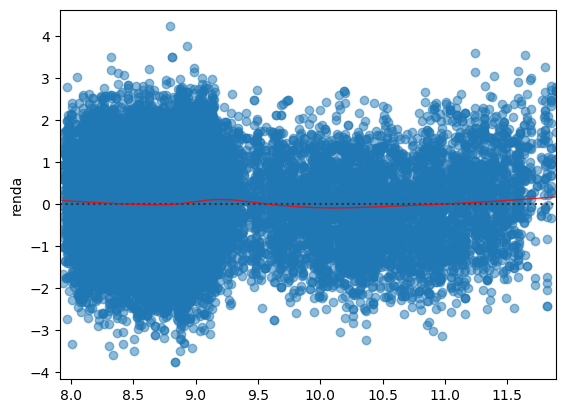

In [162]:
sns.residplot(
    x=y_pred,
    y=np.log(df_resid_check['renda'] + 1),
    data=df_resid_check,
    lowess=True,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red", "lw": 1, "alpha": 0.8},
)

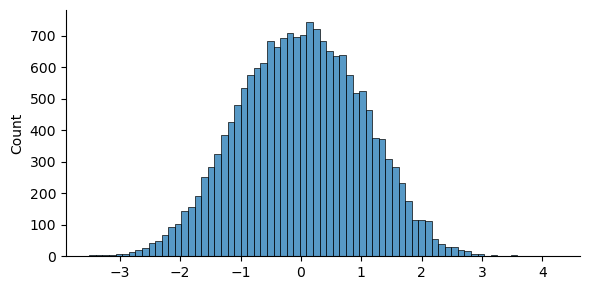

In [163]:
sns.displot(res_segmentada.resid, height=3, aspect=2);

## Outliers

Avalie os *studentized residuals*, verifique se há pontos que parecem ser discrepantes.

Avalie se há pontos influentes.

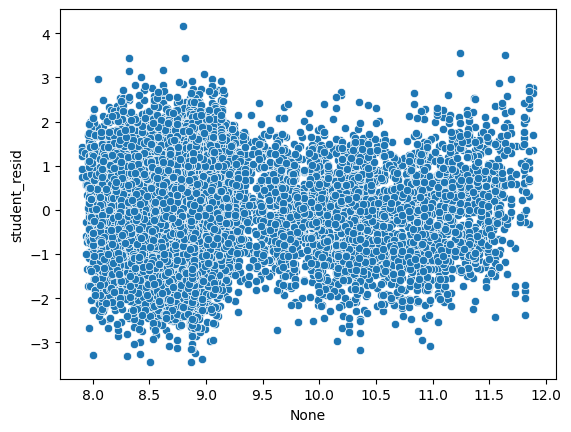

In [164]:
st_res = res_segmentada.outlier_test()
sns.scatterplot(x = y_pred, y = st_res.student_resid);

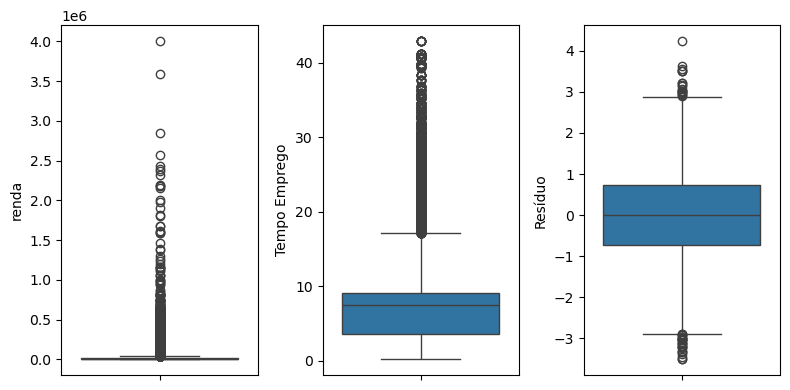

In [165]:
fig, ax = plt.subplots(1,3, figsize=(8,4))


sns.boxplot(y='renda', data=df_resid_check, ax=ax[0])
sns.boxplot(y='tempo_emprego', data=df_resid_check, ax=ax[1])
sns.boxplot(y=res_segmentada.resid, data=df_resid_check, ax=ax[2])

ax[0].set_ylabel('renda')
ax[1].set_ylabel('Tempo Emprego')
ax[2].set_ylabel('Resíduo');

plt.tight_layout()

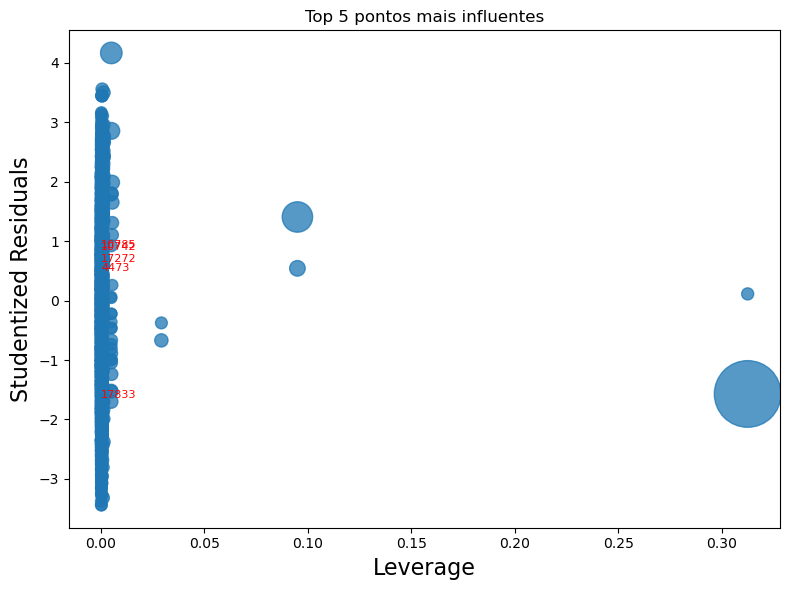

,dfb_Intercept,dfb_I(np.log(X1_1 + 2)),dfb_I(np.log(X1_2 + 2)),dfb_I(np.log(X2_1 + 2)),dfb_I(np.log(X2_2 + 2)),dfb_I(np.log(X3_1 + 2)),dfb_I(np.log(X3_2 + 2)),cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
17833,0.758382,0.003673,0.002904,0.056129,-1.057263,-0.000108,0.006383,0.160165,-1.570613,0.312475,-1.058846,-1.570677,-1.058889
17272,-0.325776,-0.000277,-0.002214,-0.010772,0.454143,-0.001490,-0.004690,0.029689,1.407396,0.094958,0.455877,1.407434,0.455889
10742,-0.184080,0.003046,-0.002084,0.073151,0.273942,-0.029888,0.027994,0.012579,4.165997,0.005048,0.296740,4.167892,0.296875
4473,-0.126160,0.002087,-0.001428,0.050135,0.187748,-0.020484,0.019186,0.005912,2.855915,0.005048,0.203424,2.856484,0.203465
10785,-0.125721,-0.000107,-0.000855,-0.004157,0.175260,-0.000575,-0.001810,0.004422,0.543158,0.094958,0.175937,0.543148,0.175934


In [166]:
influence = res_segmentada.get_influence()
summary_inf = influence.summary_frame()

# Define critérios
outlier_condition = (
    (np.abs(summary_inf["student_resid"]) > 3) |
    (summary_inf["cooks_d"] > 4 / len(df_treino))
)

# Descobre os valores "extremos"
df_outliers = X_train_.join(y_test_)[outlier_condition]

# Calcula influência
influence = res_segmentada.get_influence()
summary_frame = influence.summary_frame()
top_points = summary_frame.sort_values("cooks_d", ascending=False).head(5)

# Plot básico
fig, ax = plt.subplots(figsize=(8, 6))
influence_plot(res_segmentada, ax=ax, criterion="cooks", alpha=0.5, labels=None)

for text in ax.texts:
    text.set_visible(False)

# Adiciona apenas os 5 pontos mais influentes
for i in top_points.index:
    x = influence.hat_matrix_diag[i]
    y = influence.resid_studentized_external[i]
    ax.annotate(i, (x, y), fontsize=8, color='red')

plt.title("Top 5 pontos mais influentes")
plt.tight_layout()
plt.show()

top_points


## Ajustes

Faça os ajustes que julgar necessários no modelo e compare as métricas de desempenho do modelo original e ajustado na base de testes.

Regressão com variáveis dummies

In [187]:
formula = 'I(np.log(renda + 1)) ~ C(sexo) + C(posse_de_veiculo) + C(qtd_filhos) + C(tipo_renda) + C(estado_civil) + I(np.log( X1_1 + 2)) + I(np.log(X1_2+ 2)) + I(np.log(X3_1+ 2)) + I(np.log(X3_2+ 2))'

In [188]:
# Ajusta o modelo de regressão linear segmentado usando as transformações logarítmicas das variáveis segmentadas
reg_final = smf.ols(formula, data=X_train_.join(y_train_)).fit() 
reg_final.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                             
================================================================================
Dep. Variable:     I(np.log(renda + 1))   R-squared:                       0.378
Model:                              OLS   Adj. R-squared:                  0.377
Method:                   Least Squares   F-statistic:                     519.5
Date:                  Mon, 14 Jul 2025   Prob (F-statistic):               0.00
Time:                          20:54:48   Log-Likelihood:                -25740.
No. Observations:                 18000   AIC:                         5.152e+04
Df Residuals:                     17978   BIC:                         5.170e+04
Df Model:                            21                                         
Covariance Type:              nonrobust                                         
=====================================================================================================
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                             5.5253      0.213     25.889      0.000       5.107       5.944
C(sexo)[T.M]                          0.1180      0.018      6.664      0.000       0.083       0.153
C(posse_de_veiculo)[T.S]              0.0031      0.017      0.182      0.856      -0.030       0.036
C(qtd_filhos)[T.1]                    0.0309      0.021      1.484      0.138      -0.010       0.072
C(qtd_filhos)[T.2]                    0.0021      0.028      0.073      0.942      -0.053       0.058
C(qtd_filhos)[T.3]                   -0.1298      0.069     -1.884      0.060      -0.265       0.005
C(qtd_filhos)[T.4]                    0.2060      0.192      1.075      0.283      -0.170       0.582
C(qtd_filhos)[T.5]                   -0.3246      0.716     -0.453      0.650      -1.728       1.078
C(qtd_filhos)[T.7]                    1.4733      0.716      2.059      0.040       0.071       2.876
C(qtd_filhos)[T.14]                   0.0137      0.716      0.019      0.985      -1.390       1.418
C(tipo_renda)[T.Bolsista]            -0.6894      0.453     -1.522      0.128      -1.577       0.199
C(tipo_renda)[T.Empresário]           0.1643      0.019      8.641      0.000       0.127       0.202
C(tipo_renda)[T.Pensionista]         -0.2534      0.031     -8.266      0.000      -0.313      -0.193
C(tipo_renda)[T.Servidor público]     0.1560      0.028      5.552      0.000       0.101       0.211
C(estado_civil)[T.Separado]           0.0189      0.034      0.564      0.573      -0.047       0.085
C(estado_civil)[T.Solteiro]           0.0104      0.025      0.422      0.673      -0.038       0.059
C(estado_civil)[T.União]             -0.0451      0.029     -1.574      0.115      -0.101       0.011
C(estado_civil)[T.Viúvo]             -0.0509      0.039     -1.318      0.188      -0.127       0.025
I(np.log(X1_1 + 2))                   0.7157      0.019     38.147      0.000       0.679       0.752
I(np.log(X1_2 + 2))                   0.9418      0.016     58.721      0.000       0.910       0.973
I(np.log(X3_1 + 2))                   0.2965      0.060      4.924      0.000       0.179       0.415
I(np.log(X3_2 + 2))                   0.0200      0.015      1.355      0.175      -0.009       0.049
==============================================================================
Omnibus:                       86.280   Durbin-Watson:                   2.013
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               64.020
Skew:                          -0.032   Prob(JB):                     1.25e-14
Kurtosis:                       2.715   Cond. No.                         450.
==============================================================================

Notes:
[1] Standard Errors assume th

In [189]:
# Cálculo de R-Quadrado
tss_test = ((y_test_ - y_test_.mean()) ** 2).sum()
rss_test = ((y_test_ - reg_final.predict(X_test_)) ** 2).sum()
r_quadrado_test = 1 - rss_test / tss_test

# Cálculo de R-Quadrado Ajustado
qtd_variaveis_explicativas = len(reg_final.params) - 1
r_quadrado_ajustado_teste = 1 - (1 - r_quadrado_test) * (len(y_test_) - 1) / (
    len(y_test_) - qtd_variaveis_explicativas - 1
)

In [214]:
# Cálculo de R-Quadrado
tss_test = ((y_test_ - y_test_.mean()) ** 2).sum()
rss_test = ((y_test_ - res_segmentada.predict(X_test_)) ** 2).sum()
r_quadrado_test = 1 - rss_test / tss_test

# Cálculo de R-Quadrado Ajustado
qtd_variaveis_explicativas = len(res_segmentada.params) - 1
r_quadrado_ajustado_teste = 1 - (1 - r_quadrado_test) * (len(y_test_) - 1) / (
    len(y_test_) - qtd_variaveis_explicativas - 1
)

R-quadrado: -7.34%
R-quadrado Ajustado: -7.53%


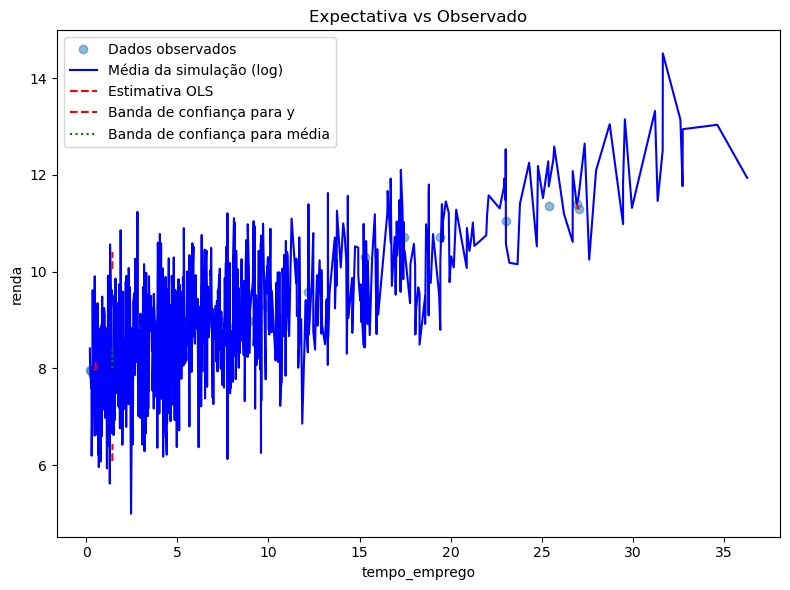

In [201]:
print(f'R-quadrado: {r_quadrado_test:.2%}')
print(f'R-quadrado Ajustado: {r_quadrado_ajustado_teste:.2%}')
esp_vs_obs(data=df_resid_check, res=reg_final, X='tempo_emprego', y_true='renda', y_pred = reg_final.predict(X_test_), transformar=True, amostragem=True);

Regressão apenas com as variáveis numéricas

R-quadrado: -7.34%
R-quadrado Ajustado: -7.38%


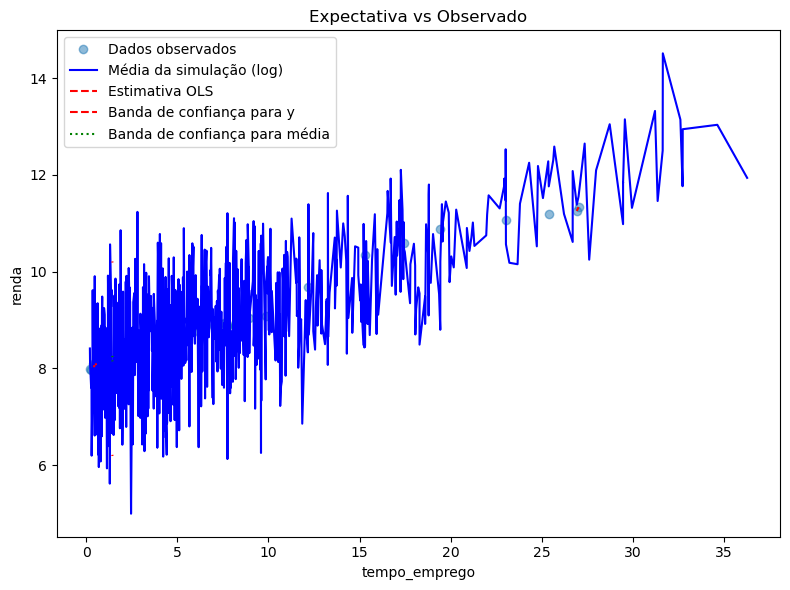

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                             
================================================================================
Dep. Variable:     I(np.log(renda + 1))   R-squared:                       0.368
Model:                              OLS   Adj. R-squared:                  0.368
Method:                   Least Squares   F-statistic:                     1746.
Date:                  Mon, 14 Jul 2025   Prob (F-statistic):               0.00
Time:                          21:26:36   Log-Likelihood:                -25879.
No. Observations:                 18000   AIC:                         5.177e+04
Df Residuals:                     17993   BIC:                         5.183e+04
Df Model:                             6                                         
Covariance Type:              nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               5.4848      0.299     18.316      0.000       4.898       6.072
I(np.log(X1_1 + 2))     0.6615      0.018     36.327      0.000       0.626       0.697
I(np.log(X1_2 + 2))     0.9997      0.015     67.080      0.000       0.971       1.029
I(np.log(X2_1 + 2))    -0.0069      0.033     -0.208      0.835      -0.072       0.059
I(np.log(X2_2 + 2))     0.4112      0.312      1.317      0.188      -0.201       1.023
I(np.log(X3_1 + 2))     0.3000      0.060      5.028      0.000       0.183       0.417
I(np.log(X3_2 + 2))    -0.0840      0.012     -7.096      0.000      -0.107      -0.061
==============================================================================
Omnibus:                       80.209   Durbin-Watson:                   2.013
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               59.939
Skew:                          -0.028   Prob(JB):                     9.65e-14
Kurtosis:                       2.723   Cond. No.                         253.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [220]:
print(f'R-quadrado: {r_quadrado_test:.2%}')
print(f'R-quadrado Ajustado: {r_quadrado_ajustado_teste:.2%}')
esp_vs_obs(data=df_resid_check, res=res_segmentada, X='tempo_emprego', y_true='renda', y_pred = res_segmentada.predict(X_test_), transformar=True, amostragem=True);
res_segmentada.summary()

In [221]:
X_train_clean = X_train_[['X1_1', 'X1_2', 'X2_1', 'X2_2', 'X3_1', 'X3_2']]

results = stepwise_selection(X_train_clean, y_train_)

print('\nVariáveis selecionadas:')
print(results)


Add  X1_2                           with p-value 0.0
Add  X3_2                           with p-value 0.000117901
Add  X1_1                           with p-value 1.52072e-06
Add  X3_1                           with p-value 0.00132714

Variáveis selecionadas:
['X1_2', 'X3_2', 'X1_1', 'X3_1']


In [217]:
# Ajusta o modelo de regressão linear segmentado usando as transformações logarítmicas das variáveis segmentadas
res_segmentada = smf.ols('I(np.log(renda+1)) ~ I(np.log(X1_1 + 2)) + I(np.log(X1_2 + 2)) + I(np.log(X3_1 + 2))  + I(np.log(X3_2 + 2))', data=X_train_.join(y_train_)).fit() 
res_segmentada.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                             
================================================================================
Dep. Variable:     I(np.log(renda + 1))   R-squared:                       0.368
Model:                              OLS   Adj. R-squared:                  0.368
Method:                   Least Squares   F-statistic:                     2618.
Date:                  Mon, 14 Jul 2025   Prob (F-statistic):               0.00
Time:                          21:25:47   Log-Likelihood:                -25880.
No. Observations:                 18000   AIC:                         5.177e+04
Df Residuals:                     17995   BIC:                         5.181e+04
Df Model:                             4                                         
Covariance Type:              nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               5.7585      0.209     27.540      0.000       5.349       6.168
I(np.log(X1_1 + 2))     0.6614      0.018     36.348      0.000       0.626       0.697
I(np.log(X1_2 + 2))     0.9997      0.015     67.137      0.000       0.971       1.029
I(np.log(X3_1 + 2))     0.3014      0.060      5.056      0.000       0.185       0.418
I(np.log(X3_2 + 2))    -0.0835      0.011     -7.456      0.000      -0.105      -0.062
==============================================================================
Omnibus:                       78.940   Durbin-Watson:                   2.013
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               59.121
Skew:                          -0.027   Prob(JB):                     1.45e-13
Kurtosis:                       2.725   Cond. No.                         134.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

R-quadrado: -7.34%
R-quadrado Ajustado: -7.38%


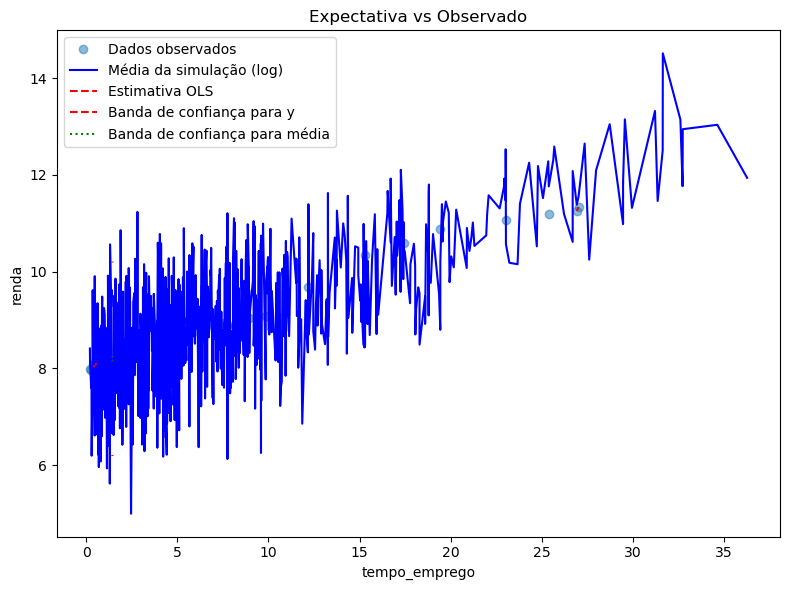

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                             
================================================================================
Dep. Variable:     I(np.log(renda + 1))   R-squared:                       0.368
Model:                              OLS   Adj. R-squared:                  0.368
Method:                   Least Squares   F-statistic:                     2618.
Date:                  Mon, 14 Jul 2025   Prob (F-statistic):               0.00
Time:                          21:26:10   Log-Likelihood:                -25880.
No. Observations:                 18000   AIC:                         5.177e+04
Df Residuals:                     17995   BIC:                         5.181e+04
Df Model:                             4                                         
Covariance Type:              nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               5.7585      0.209     27.540      0.000       5.349       6.168
I(np.log(X1_1 + 2))     0.6614      0.018     36.348      0.000       0.626       0.697
I(np.log(X1_2 + 2))     0.9997      0.015     67.137      0.000       0.971       1.029
I(np.log(X3_1 + 2))     0.3014      0.060      5.056      0.000       0.185       0.418
I(np.log(X3_2 + 2))    -0.0835      0.011     -7.456      0.000      -0.105      -0.062
==============================================================================
Omnibus:                       78.940   Durbin-Watson:                   2.013
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               59.121
Skew:                          -0.027   Prob(JB):                     1.45e-13
Kurtosis:                       2.725   Cond. No.                         134.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [218]:
print(f'R-quadrado: {r_quadrado_test:.2%}')
print(f'R-quadrado Ajustado: {r_quadrado_ajustado_teste:.2%}')
esp_vs_obs(data=df_resid_check, res=res_segmentada, X='tempo_emprego', y_true='renda', y_pred = res_segmentada.predict(X_test_), transformar=True, amostragem=True);
res_segmentada.summary()